# TOA / datetime / rotated-geopotential perturbation experiments (GraphCast)

Runs and plots in a single notebook. These experiments are small -- about eight
forecasts in total, against the 365 per test case of the main
spatial-generalization pipeline -- so generation and plotting are kept together
here.

Produces four of the paper's figures:

- `toa_datetime_perturbation_linearity.png`
- `toa_datetime_rmse_vs_leadtime.png`
- `input_transformations_overview.jpeg`
- `rotated_geopotential_effect.png`

**Running the model is optional.** The forecasts are gated behind
`REGENERATE_FROM_SCRATCH` (default `False`): by default the notebook downloads the
precomputed predictions and goes straight to plotting, which needs no GPU. Set the
flag to `True` only if you want to produce the forecasts yourself. The
download-and-plot path is the one that has been tested end to end.

Portions of this notebook are adapted from Google DeepMind's GraphCast demo
(<https://github.com/google-deepmind/weathernext>, formerly
`github.com/deepmind/graphcast`) -- the imports, the model construction/wrapping helpers
(`construct_wrapped_graphcast`, `run_forward`, `with_configs`, `with_params`,
`drop_state`) and the `rollout.chunked_prediction` call.
**That code has been modified for this project.** The full Apache License 2.0
text is in `LICENSE-APACHE-2.0` in this folder.

> <p><small><small>Copyright 2023 DeepMind Technologies Limited.</small></p>
> <p><small><small>Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at <a href="http://www.apache.org/licenses/LICENSE-2.0">http://www.apache.org/licenses/LICENSE-2.0</a>.</small></small></p>
> <p><small><small>Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.</small></small></p>


## Config

In [1]:
import sys, os
sys.path.insert(0, "../common")
from zenodo_fetch import ensure_zenodo_files

DATA_DIR = "../data/GraphCast/simulation_outputs"

# The figures below are written here.
os.makedirs("figures", exist_ok=True)

# Set True to re-run GraphCast and regenerate the prediction files from
# scratch instead of using the already-provided ones. Heavy: ~8 forecasts,
# each a 40-step autoregressive rollout.
REGENERATE_FROM_SCRATCH = False

# --- TEMPORARY: data is on Zenodo's sandbox while the paper is under review ---
# Sandbox records are periodically wiped and their DOIs (10.5072/...) are not
# real. When the record is published on the real Zenodo, delete these two lines
# and replace the record id(s) below with the real one(s).
import os
os.environ["ZENODO_BASE_URL"] = "https://sandbox.zenodo.org"
# -----------------------------------------------------------------------------

# Zenodo record holding GraphCast's ERA5, climatology and simulation-input
# data. See README.md for what each record contains.
ZENODO_RECORD_GRAPHCAST_ERA5 = "586387"

## Setup (adapted from the GraphCast Demo)


In [2]:
import dataclasses
import functools
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from google.cloud import storage
from graphcast import autoregressive
from graphcast import casting
from graphcast import checkpoint
from graphcast import data_utils
from graphcast import graphcast
from graphcast import normalization
from graphcast import rollout
from graphcast import xarray_jax
from graphcast import xarray_tree
import haiku as hk
import ipywidgets as widgets
import jax
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import xarray 
import cmocean
from matplotlib import gridspec
from scipy.stats import gaussian_kde, linregress

def parse_file_parts(file_name):
    return dict(part.split("-", 1) for part in file_name.split("_"))


In [3]:
gcs_client = storage.Client.create_anonymous_client()
gcs_bucket = gcs_client.get_bucket("dm_graphcast")
dir_prefix = "graphcast/"

In [4]:
with gcs_bucket.blob(dir_prefix + "stats/diffs_stddev_by_level.nc").open("rb") as f:
    diffs_stddev_by_level = xarray.load_dataset(f).compute()
with gcs_bucket.blob(dir_prefix + "stats/mean_by_level.nc").open("rb") as f:
    mean_by_level = xarray.load_dataset(f).compute()
with gcs_bucket.blob(dir_prefix + "stats/stddev_by_level.nc").open("rb") as f:
    stddev_by_level = xarray.load_dataset(f).compute()

In [5]:
def construct_wrapped_graphcast(model_config, task_config):
    predictor = graphcast.GraphCast(model_config, task_config)
    predictor = casting.Bfloat16Cast(predictor)
    predictor = normalization.InputsAndResiduals(
        predictor,
        diffs_stddev_by_level=diffs_stddev_by_level,
        mean_by_level=mean_by_level,
        stddev_by_level=stddev_by_level)
    predictor = autoregressive.Predictor(predictor, gradient_checkpointing=True)
    return predictor

@hk.transform_with_state
def run_forward(model_config, task_config, inputs, targets_template, forcings):
    predictor = construct_wrapped_graphcast(model_config, task_config)
    return predictor(inputs, targets_template=targets_template, forcings=forcings)

@hk.transform_with_state
def loss_fn(model_config, task_config, inputs, targets, forcings):
    predictor = construct_wrapped_graphcast(model_config, task_config)
    loss, diagnostics = predictor.loss(inputs, targets, forcings)
    return xarray_tree.map_structure(
        lambda x: xarray_jax.unwrap_data(x.mean(), require_jax=True),
        (loss, diagnostics))

def with_configs(fn):
    return functools.partial(fn, model_config=model_config, task_config=task_config)

def with_params(fn):
    return functools.partial(fn, params=params, state=state)

def drop_state(fn):
    return lambda **kw: fn(**kw)[0]

### Load the model

Loads the **GraphCast_small** checkpoint. Only its `model_config` / `task_config`
metadata is needed at this point (for `data_utils.extract_inputs_targets_forcings`
below), so this is cheap I/O rather than a model run.

In [6]:
PARAMS_FILE = "GraphCast_small - ERA5 1979-2015 - resolution 1.0 - pressure levels 13 - mesh 2to5 - precipitation input and output.npz"

with gcs_bucket.blob(f"{dir_prefix}params/{PARAMS_FILE}").open("rb") as f:
    ckpt = checkpoint.load(f, graphcast.CheckPoint)
params = ckpt.params
state = {}
model_config = ckpt.model_config
task_config = ckpt.task_config
print("Model description:\n", ckpt.description)
model_config


Model description:
 
Low resolution version of the GraphCast model (1deg, smaller mesh), with 37
pressure levels. This model is trained on ERA5 data from 1979 to 2015, and can
be causally evaluated on 2016 and later years. This model takes as inputs
`total_precipitation_6hr`. This model has much lower memory requirements.



ModelConfig(resolution=1.0, mesh_size=5, latent_size=512, gnn_msg_steps=16, hidden_layers=1, radius_query_fraction_edge_length=0.6, mesh2grid_edge_normalization_factor=0.6180338738074472)

### Load the example data

Uses the GraphCast demo dataset: source `era5`, date 2022-01-01, resolution 1.0,
13 pressure levels.

In [7]:
def data_valid_for_model(file_name, model_config, task_config):
    file_parts = parse_file_parts(file_name.removesuffix(".nc"))
    return (
        model_config.resolution in (0, float(file_parts["res"])) and
        len(task_config.pressure_levels) == int(file_parts["levels"]) and
        (("total_precipitation_6hr" in task_config.input_variables and
          file_parts["source"] in ("era5", "fake")) or
         ("total_precipitation_6hr" not in task_config.input_variables and
          file_parts["source"] in ("hres", "fake"))))

DATASET_FILE = "source-era5_date-2022-01-01_res-1.0_levels-13_steps-40.nc"
assert data_valid_for_model(DATASET_FILE, model_config, task_config)

with gcs_bucket.blob(f"{dir_prefix}dataset/{DATASET_FILE}").open("rb") as f:
    example_batch = xarray.load_dataset(f).compute()

assert example_batch.dims["time"] >= 3
print(", ".join([f"{k}: {v}" for k, v in parse_file_parts(DATASET_FILE.removesuffix(".nc")).items()]))


source: era5, date: 2022-01-01, res: 1.0, levels: 13, steps: 40


In [8]:
sim1_ini = example_batch.copy()


---
## Simulations 1: TOA / Datetime perturbations

Four simulations: (1) Normal, (2) Datetime shifted back 12h, (3) TOA incident solar radiation rolled 180deg longitude, (4) both.

### Generate from scratch (optional -- see Config)

In [9]:
if REGENERATE_FROM_SCRATCH:
    def shift_datetime_12h(data: xarray.Dataset) -> xarray.Dataset:
        """Shift the datetime coordinate back by 12 h. All other fields are unchanged."""
        new_data = data.copy()
        if "datetime" in new_data.coords:
            new_data.datetime.values = (new_data.datetime - np.timedelta64(12, "h")).values
        return new_data


    def shift_toa_180lon(data: xarray.Dataset) -> xarray.Dataset:
        """Roll toa_incident_solar_radiation by 180 degrees in longitude. Everything else is unchanged."""
        new_data = data.copy()
        if "toa_incident_solar_radiation" in new_data.data_vars:
            n_lon = new_data.sizes["lon"]
            new_data["toa_incident_solar_radiation"] = (
                new_data["toa_incident_solar_radiation"].roll(lon=n_lon // 2, roll_coords=False)
            )
        return new_data

In [10]:
if REGENERATE_FROM_SCRATCH:
    # 1. Normal – no modification
    sim1_ini = example_batch.copy()

    # 2. Datetime shifted back by 12 h only
    sim2_ini = shift_datetime_12h(example_batch.copy())

    # 3. TOA incident solar radiation shifted by 180° longitude only
    sim3_ini = shift_toa_180lon(example_batch.copy())

    # 4. Both perturbations applied simultaneously
    sim4_ini = shift_datetime_12h(shift_toa_180lon(example_batch.copy()))

    print("Sim 1 datetime (normal):         ", sim1_ini.datetime.values[0][0])
    print("Sim 2 datetime (+12h shift):      ", sim2_ini.datetime.values[0][0])
    print("Sim 3 datetime (TOA shift only):  ", sim3_ini.datetime.values[0][0])
    print("Sim 4 datetime (both):            ", sim4_ini.datetime.values[0][0])

In [11]:
if REGENERATE_FROM_SCRATCH:
    def run_model(input_data: xarray.Dataset) -> xarray.Dataset:
        """Run a 10-day (40 × 6 h) GraphCast forecast and return surface variables."""
        eval_steps = 40

        eval_inputs, eval_targets, eval_forcings = data_utils.extract_inputs_targets_forcings(
            input_data,
            target_lead_times=slice("6h", f"{eval_steps * 6}h"),
            **dataclasses.asdict(task_config))

        run_forward_jitted = drop_state(with_params(jax.jit(with_configs(run_forward.apply))))

        predictions = rollout.chunked_prediction(
            run_forward_jitted,
            rng=jax.random.PRNGKey(0),
            inputs=eval_inputs,
            targets_template=eval_targets * np.nan,
            forcings=eval_forcings)

        # Keep only surface variables to reduce memory usage
        drop_vars = ["temperature", "geopotential", "u_component_of_wind", "v_component_of_wind"]
        predictions = predictions.drop_vars(drop_vars)
        return predictions.sel(level=1000, method="nearest")

In [12]:
if REGENERATE_FROM_SCRATCH:
    os.makedirs(f"{DATA_DIR}/TOA_and_time_pertubations", exist_ok=True)

    print("Running simulation 1: Normal ...")
    sim1_pred = run_model(sim1_ini.copy())
    sim1_pred.to_netcdf(f"{DATA_DIR}/TOA_and_time_pertubations/pred1.nc")

    print("Running simulation 2: Datetime shifted by 12 h ...")
    sim2_pred = run_model(sim2_ini.copy())
    sim2_pred.to_netcdf(f"{DATA_DIR}/TOA_and_time_pertubations/pred2.nc")

    print("Running simulation 3: TOA shifted by 180° longitude ...")
    sim3_pred = run_model(sim3_ini.copy())
    sim3_pred.to_netcdf(f"{DATA_DIR}/TOA_and_time_pertubations/pred3.nc")

    print("Running simulation 4: Both perturbations ...")
    sim4_pred = run_model(sim4_ini.copy())
    sim4_pred.to_netcdf(f"{DATA_DIR}/TOA_and_time_pertubations/pred4.nc")

    print("Done!")


### Fetch predictions (default)

In [13]:
ensure_zenodo_files(ZENODO_RECORD_GRAPHCAST_ERA5, {
    "pred1.nc": "43206dfbd37c4fa4fd7d268d4b800de6",
    "pred2.nc": "295de7ac1bf3b0831e678f37181824a9",
    "pred3.nc": "989ed32f36d485e18c407f195b107286",
    "pred4.nc": "13c97f2332f5dffa975186ac1818aee2",
}, f"{DATA_DIR}/TOA_and_time_pertubations")

sim1_pred = xarray.open_dataset(f"{DATA_DIR}/TOA_and_time_pertubations/pred1.nc")
sim2_pred = xarray.open_dataset(f"{DATA_DIR}/TOA_and_time_pertubations/pred2.nc")
sim3_pred = xarray.open_dataset(f"{DATA_DIR}/TOA_and_time_pertubations/pred3.nc")
sim4_pred = xarray.open_dataset(f"{DATA_DIR}/TOA_and_time_pertubations/pred4.nc")


---
## Plot 1 -- spatial map comparison and linearity test

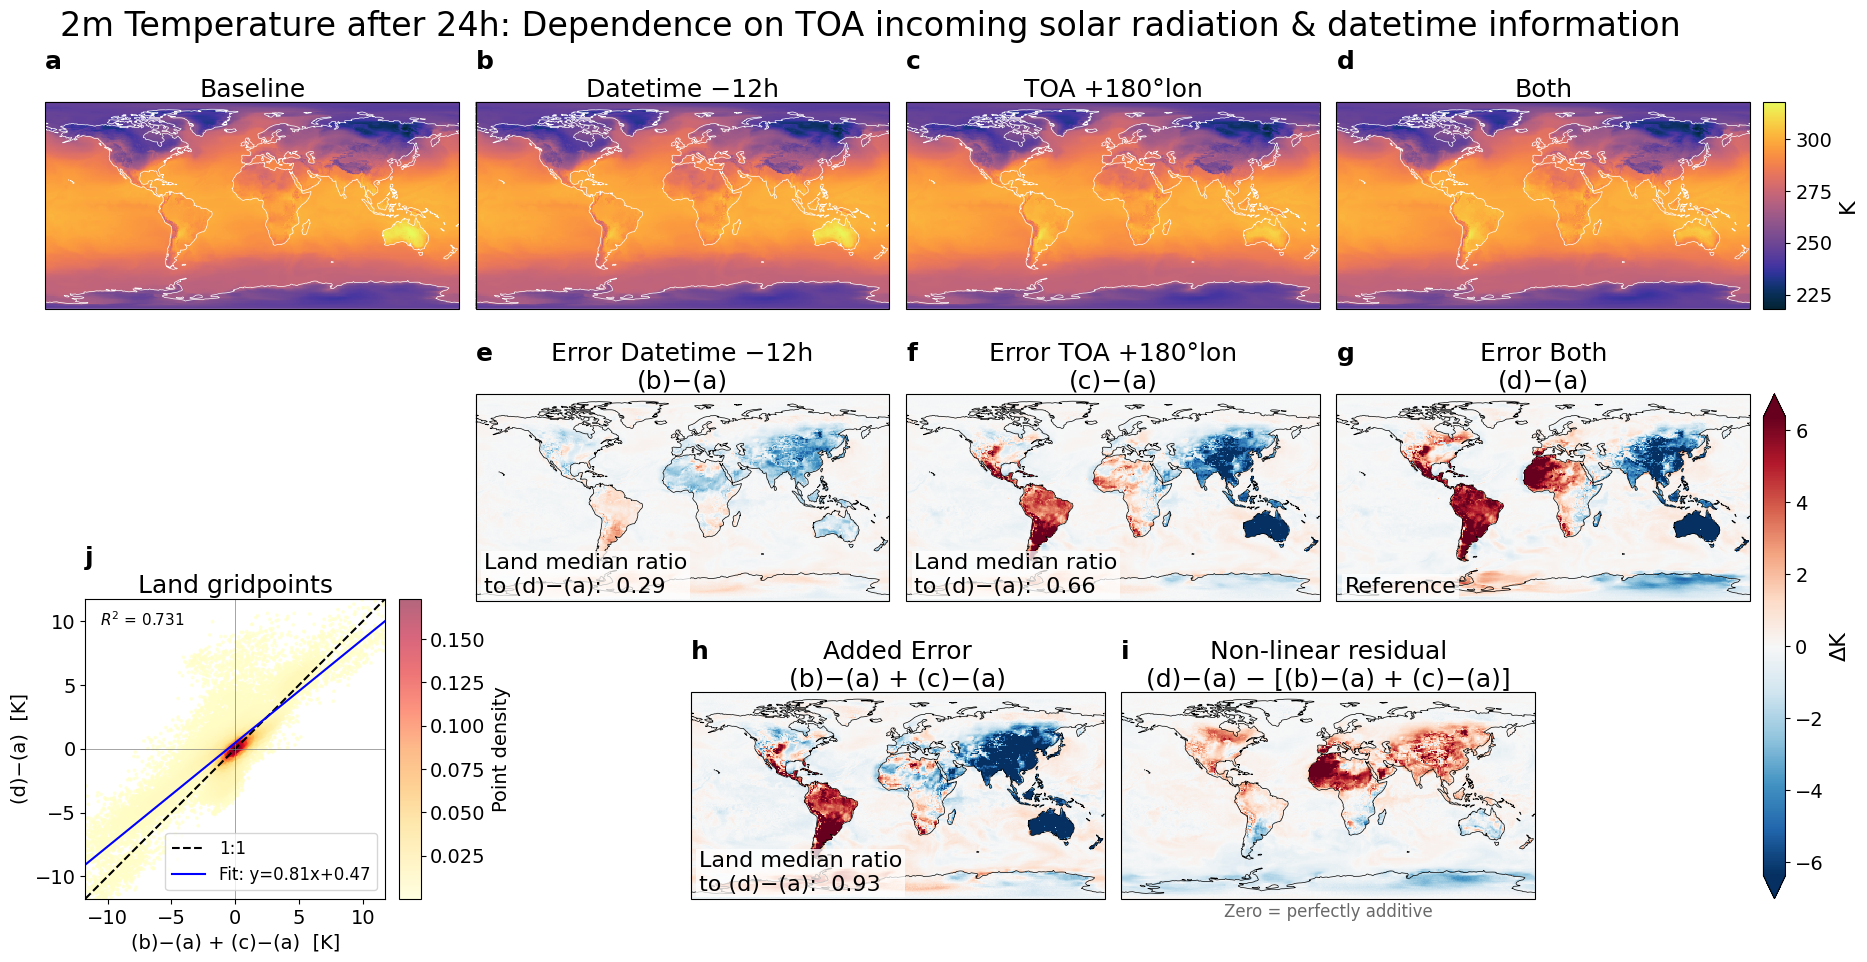

In [14]:
from scipy.stats import gaussian_kde

# ── User-adjustable settings ──────────────────────────────────────────────────
SNAPSHOT_DAY = 1
VAR          = "2m_temperature"
threshold    = 0.01
# ─────────────────────────────────────────────────────────────────────────────

time_idx = SNAPSHOT_DAY * 4 - 1

preds  = [sim1_pred, sim2_pred, sim3_pred, sim4_pred]
labels = ["Baseline", "Datetime −12h", "TOA +180°lon", "Both"]

fields = [p[VAR].isel(time=time_idx).squeeze().values for p in preds]
diffs  = [f - fields[0] for f in fields[1:]]

lons = sim1_pred.lon.values
lats = sim1_pred.lat.values
proj = ccrs.PlateCarree()

# ── Linearity fields ──────────────────────────────────────────────────────────
diff_2_1   = diffs[0]
diff_3_1   = diffs[1]
diff_4_1   = diffs[2]
linear_sum = diff_2_1 + diff_3_1
residual   = diff_4_1 - linear_sum

# ── Land mask & ratios ────────────────────────────────────────────────────────
lsm  = sim1_ini["land_sea_mask"].squeeze().values
land = lsm > 0.5

denom = diff_4_1.copy().astype(float)
denom[np.abs(denom) < threshold] = np.nan

med_r2  = np.nanmedian(np.where(land, diff_2_1   / denom, np.nan))
med_r3  = np.nanmedian(np.where(land, diff_3_1   / denom, np.nan))
med_rls = np.nanmedian(np.where(land, linear_sum / denom, np.nan))

# ── Colour scales ─────────────────────────────────────────────────────────────
vmin_a   = min(f.min() for f in fields)
vmax_a   = max(f.max() for f in fields)

diff_max_full = max(np.abs(d).max() for d in [diff_2_1, diff_3_1, linear_sum, diff_4_1])
all_diff_vals = np.concatenate([d.ravel() for d in [diff_2_1, diff_3_1, linear_sum, diff_4_1, residual]])
diff_max      = np.nanpercentile(np.abs(all_diff_vals), 98)

# ── Scatter data (land only) ──────────────────────────────────────────────────
x = linear_sum[land].ravel()
y = diff_4_1[land].ravel()
mask_valid = np.isfinite(x) & np.isfinite(y)
x, y = x[mask_valid], y[mask_valid]
color = gaussian_kde(np.vstack([x, y]))(np.vstack([x, y]))

# ── Figure: 3 rows × 4 cols via GridSpec ─────────────────────────────────────
fig = plt.figure(figsize=(22, 13))
fig.suptitle(
    f"2m Temperature after 24h: Dependence on TOA incoming solar radiation & datetime information",
    fontsize=24, y=0.87
)

gs = gridspec.GridSpec(3, 4, hspace=-0.3, wspace=0.04)

# ── Row 0: Absolute fields (cols 0–3) ────────────────────────────────────────
# "\n" prefix: blank first line so title text sits at second-line height,
# matching two-line titles in rows 1–2. Labels (a–d) occupy the first line.
top_axes = []
for i, (field, label) in enumerate(zip(fields, labels)):
    ax = fig.add_subplot(gs[0, i], projection=proj)
    ax.set_global()
    im_top = ax.pcolormesh(lons, lats, field,
                           vmin=vmin_a, vmax=vmax_a,
                           cmap=cmocean.cm.thermal, transform=proj)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="white")
    ax.set_title("\n" + label, fontsize=18, pad=4)
    top_axes.append(ax)

# ── Row 1: Diff panels under (2), (3), (4) — col 0 empty ────────────────────
row1_panels = [diff_2_1, diff_3_1, diff_4_1]
row1_titles = ["Error Datetime −12h\n(b)−(a)",
               "Error TOA +180°lon\n(c)−(a)",
               "Error Both\n(d)−(a)"]
row1_meds   = [f"Land median ratio\nto (d)−(a):  {med_r2:.2f}",
               f"Land median ratio\nto (d)−(a):  {med_r3:.2f}",
               "Reference"]

mid_axes = []
for i, (panel, title, med_txt) in enumerate(zip(row1_panels, row1_titles, row1_meds)):
    ax = fig.add_subplot(gs[1, i + 1], projection=proj)
    ax.set_global()
    im_mid = ax.pcolormesh(lons, lats, panel,
                           vmin=-diff_max, vmax=diff_max,
                           cmap="RdBu_r", transform=proj)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.set_title(title, fontsize=18, pad=4)
    ax.text(0.02, 0.04, med_txt, transform=ax.transAxes, fontsize=16,
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=2))
    mid_axes.append(ax)

# ── Draw to lock positions before placing row 2 manually ─────────────────────
fig.canvas.draw()

p1 = [ax.get_position() for ax in mid_axes]
p0 = [ax.get_position() for ax in top_axes]

col_w = p1[0].x1 - p1[0].x0
row_h = p1[0].y1 - p1[0].y0
gap   = 0.07

y0_row2 = p1[0].y0 - gap - row_h

# Scatter: aligned with col 0
scale  = 1.45
sc_pos = [p0[0].x0 - 0.05, y0_row2, col_w * scale, row_h * scale]

# Linear sum: centred between (b)-(a) and (c)-(a)
ls_cx  = (p1[0].x1 + p1[1].x0) / 2
ls_pos = [ls_cx - col_w / 2, y0_row2, col_w, row_h]

# Residual: centred between (c)-(a) and (d)-(a)
res_cx  = (p1[1].x1 + p1[2].x0) / 2
res_pos = [res_cx - col_w / 2, y0_row2, col_w, row_h]

# ── Row 2a: Linear sum map (centre-left) ─────────────────────────────────────
ax_ls = fig.add_axes(ls_pos, projection=proj)
ax_ls.set_global()
im_ls = ax_ls.pcolormesh(lons, lats, linear_sum,
                          vmin=-diff_max, vmax=diff_max,
                          cmap="RdBu_r", transform=proj)
ax_ls.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax_ls.set_title("Added Error\n(b)−(a) + (c)−(a)", fontsize=18, pad=4)
ax_ls.text(0.02, 0.04,
           f"Land median ratio\nto (d)−(a):  {med_rls:.2f}",
           transform=ax_ls.transAxes, fontsize=16,
           bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=2))

# ── Row 2b: Non-linear residual (centre-right) ───────────────────────────────
ax_res = fig.add_axes(res_pos, projection=proj)
ax_res.set_global()
im_res = ax_res.pcolormesh(lons, lats, residual,
                            vmin=-diff_max, vmax=diff_max,
                            cmap="RdBu_r", transform=proj)
ax_res.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax_res.set_title("Non-linear residual\n(d)−(a) − [(b)−(a) + (c)−(a)]",
                 fontsize=18, pad=4)
ax_res.text(0.5, -0.09, "Zero = perfectly additive",
            transform=ax_res.transAxes, ha="center", fontsize=12, color="dimgrey")

# ── Row 2c: Scatter (left) ────────────────────────────────────────────────────
ax_sc = fig.add_axes(sc_pos)
sc_plot = ax_sc.scatter(x, y, c=color, cmap="YlOrRd", s=3, alpha=0.6, rasterized=True)
lim = np.percentile(np.abs(np.concatenate([x, y])), 99)
ax_sc.plot([-lim, lim], [-lim, lim], "k--", linewidth=1.5, label="1:1")
ax_sc.axhline(0, color="grey", linewidth=0.5)
ax_sc.axvline(0, color="grey", linewidth=0.5)
slope, intercept, r_value, _, _ = linregress(x, y)
x_fit = np.linspace(-lim, lim, 200)
y_fit = slope * x_fit + intercept
ax_sc.plot(x_fit, y_fit, "b-", linewidth=1.5, label=f"Fit: y={slope:.2f}x+{intercept:.2f}")
ax_sc.set_xlim(-lim, lim)
ax_sc.set_ylim(-lim, lim)
ax_sc.set_aspect("equal", adjustable="box")
ax_sc.set_xlabel("(b)−(a) + (c)−(a)  [K]", fontsize=14)
ax_sc.set_ylabel("(d)−(a)  [K]",            fontsize=14)
ax_sc.set_title("\nLand gridpoints", fontsize=18, pad=4)
r2 = np.corrcoef(x, y)[0, 1] ** 2
ax_sc.text(0.05, 0.91, f"$R^2$ = {r2:.3f}", transform=ax_sc.transAxes, fontsize=11)
ax_sc.tick_params(labelsize=14)
ax_sc.legend(fontsize=12, loc="lower right")

# ── Subplot labels (a–j, left-aligned at first-line height) ──────────────────
_label_axes = [
    (top_axes[0], "a"),
    (top_axes[1], "b"),
    (top_axes[2], "c"),
    (top_axes[3], "d"),
    (mid_axes[0], "e"),
    (mid_axes[1], "f"),
    (mid_axes[2], "g"),
    (ax_ls,       "h"),
    (ax_res,      "i"),
    (ax_sc,       "j"),
]
for _ax, _lbl in _label_axes:
    _ax.set_title(_lbl + "\n", fontsize=18, fontweight="bold",
                  loc="left", pad=4)

# ── Colorbars ─────────────────────────────────────────────────────────────────
fig.canvas.draw()
cbar_w, cbar_pad = 0.010, 0.006

# Row 0 thermal: right of top-right panel
pos = top_axes[-1].get_position()
cax = fig.add_axes([pos.x1 + cbar_pad, pos.y0, cbar_w, pos.y1 - pos.y0])
cb  = fig.colorbar(im_top, cax=cax)
cb.set_label("K", fontsize=16)
cb.ax.tick_params(labelsize=14)

# Rows 1 & 2 diverging: tall bar spanning row-1 top to row-2 bottom
pos_r1  = mid_axes[-1].get_position()
pos_res = ax_res.get_position()
right_edge = max(pos_r1.x1, pos_res.x1)
cax2 = fig.add_axes([right_edge + cbar_pad, pos_res.y0,
                     cbar_w, pos_r1.y1 - pos_res.y0])
cb2  = fig.colorbar(im_mid, cax=cax2, extend="both")
cb2.set_label("ΔK", fontsize=16)
cb2.ax.tick_params(labelsize=14)

# Scatter density colorbar
pos_sc = ax_sc.get_position()
cax3 = fig.add_axes([pos_sc.x1 + cbar_pad, pos_sc.y0,
                     cbar_w, pos_sc.y1 - pos_sc.y0])
cb3 = fig.colorbar(sc_plot, cax=cax3)
cb3.set_label("Point density", fontsize=14)
cb3.ax.tick_params(labelsize=14)

plt.savefig("figures/toa_datetime_perturbation_linearity.png", dpi=300, bbox_inches="tight")
plt.show()

---
## Plot 2 -- Global-Mean RMSE

Area-weighted RMSE of 2 m temperature over the 10-day forecast.


In [15]:
# ERA5 targets for the forecast error reference
_, eval_targets, _ = data_utils.extract_inputs_targets_forcings(
    sim1_ini,
    target_lead_times=slice("6h", f"{40 * 6}h"),
    **dataclasses.asdict(task_config))

# Latitude weights (cos-weighting)
lat_weights = np.cos(np.deg2rad(sim1_ini.lat.values)).reshape(1, -1, 1)

def global_rmse(pred_vals: np.ndarray, ref_vals: np.ndarray) -> np.ndarray:
    """Lat-weighted global-mean RMSE, shape (time,)."""
    se = ((pred_vals - ref_vals) ** 2) * lat_weights
    return np.sqrt(np.mean(se, axis=(1, 2)))

t2m_sim1 = sim1_pred["2m_temperature"].squeeze().values
t2m_sim2 = sim2_pred["2m_temperature"].squeeze().values
t2m_sim3 = sim3_pred["2m_temperature"].squeeze().values
t2m_sim4 = sim4_pred["2m_temperature"].squeeze().values
t2m_era5 = eval_targets["2m_temperature"].squeeze().values

forecast_rmse = global_rmse(t2m_sim1, t2m_era5)   # sim1 vs ERA5
sim2_rmse     = global_rmse(t2m_sim2, t2m_sim1)   # sim2 vs sim1
sim3_rmse     = global_rmse(t2m_sim3, t2m_sim1)   # sim3 vs sim1
sim4_rmse     = global_rmse(t2m_sim4, t2m_sim1)   # sim4 vs sim1

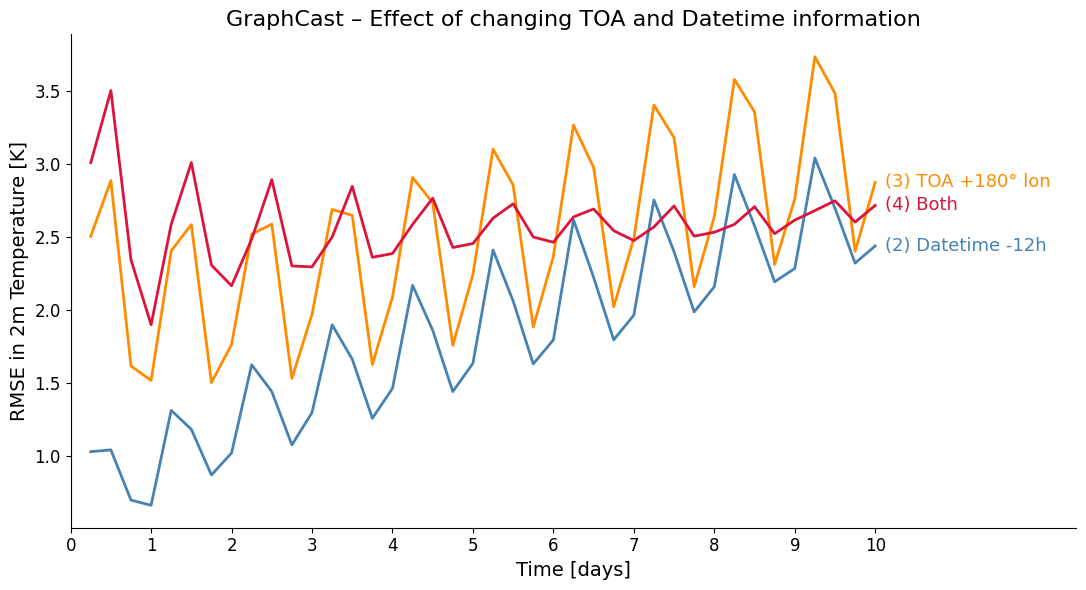

In [16]:
x = np.arange(40) + 1

lines = [
    #(forecast_rmse, "black",      "--", "Forecast error (sim 1 vs ERA5)"),
    (sim2_rmse,     "steelblue",  "-",  "(2) Datetime -12h"),
    (sim3_rmse,     "darkorange", "-",  "(3) TOA +180° lon"),
    (sim4_rmse,     "crimson",    "-",  "(4) Both"),
]

fig, ax = plt.subplots(figsize=(11, 6))

for data, color, ls, label in lines:
    ax.plot(x, data, color=color, linestyle=ls, linewidth=2)
    ax.text(
        x[-1] + 0.5, data[-1], label,
        color=color, va="center", fontsize=13,
        bbox=dict(facecolor="white", edgecolor="none", pad=1))

ax.set_xticks(np.arange(0, 41, 4))
ax.set_xticklabels(np.arange(0, 11, 1), fontsize=12)
ax.tick_params(axis="y", labelsize=12)
ax.set_xlabel("Time [days]", fontsize=14)
ax.set_ylabel("RMSE in 2m Temperature [K]", fontsize=14)
ax.set_title("GraphCast – Effect of changing TOA and Datetime information", fontsize=16)
ax.set_xlim(0, x[-1] + 10)
ax.spines[["top", "right"]].set_visible(False)

plt.savefig("figures/toa_datetime_rmse_vs_leadtime.png", dpi=800)
plt.tight_layout()
plt.show()

---
## Simulations 2: rotated geopotential-at-surface perturbation

A separate set of four runs: (1) unperturbed, (2) surface geopotential rolled by
180 deg in longitude, (3) longitude coordinates rolled by 180 deg, (4) both.
Note that this section's `run_model` keeps all variables and levels, whereas
Simulations 1 above drops non-surface variables to save memory.

### Generate from scratch (optional -- see Config)

In [17]:
if REGENERATE_FROM_SCRATCH:
    def shift_geopotential_180lon(data: xarray.Dataset) -> xarray.Dataset:
        new_data = data.copy()
        if "geopotential_at_surface" in new_data.data_vars:
            n_lon = new_data.sizes["lon"]
            new_data["geopotential_at_surface"] = (
                new_data["geopotential_at_surface"].roll(lon=n_lon // 2, roll_coords=False)
            )
        return new_data

In [18]:
if REGENERATE_FROM_SCRATCH:
    def roll_lon180(data: xarray.Dataset) -> xarray.Dataset:
        """Roll longitude coordinates by 180 degrees (e.g. 0–360 → -180–180)"""
        new_data = data.copy()
        if "lon" in new_data.coords:
            new_data = new_data.roll(lon=len(new_data.lon) // 2, roll_coords=True)
        return new_data

In [19]:
if REGENERATE_FROM_SCRATCH:
    # 1. Normal – no modification
    sim1_ini = example_batch.copy()

    # 2. revlat
    sim2_ini = shift_geopotential_180lon(example_batch.copy())

    # 3. rev geopotential
    sim3_ini = roll_lon180(example_batch.copy())

    # 4. Both perturbations applied simultaneously
    sim4_ini = shift_geopotential_180lon(roll_lon180(example_batch.copy()))

In [20]:
if REGENERATE_FROM_SCRATCH:
    def run_model(input_data: xarray.Dataset) -> xarray.Dataset:
        """Run a 10-day (40 × 6 h) GraphCast forecast and return surface variables."""
        eval_steps = 40

        eval_inputs, eval_targets, eval_forcings = data_utils.extract_inputs_targets_forcings(
            input_data,
            target_lead_times=slice("6h", f"{eval_steps * 6}h"),
            **dataclasses.asdict(task_config))

        run_forward_jitted = drop_state(with_params(jax.jit(with_configs(run_forward.apply))))

        predictions = rollout.chunked_prediction(
            run_forward_jitted,
            rng=jax.random.PRNGKey(0),
            inputs=eval_inputs,
            targets_template=eval_targets * np.nan,
            forcings=eval_forcings)

        # Keep only surface variables to reduce memory usage
       # drop_vars = ["temperature", "geopotential", "u_component_of_wind", "v_component_of_wind"]
       # predictions = predictions.drop_vars(drop_vars)
        return predictions #.sel(level=1000, method="nearest")

In [21]:
if REGENERATE_FROM_SCRATCH:
    os.makedirs(f"{DATA_DIR}/rotlon_geopot", exist_ok=True)

    print("Running simulation 1: Normal ...")
    sim1_pred = run_model(sim1_ini.copy())

    print("Running simulation 2: RevLat ...")
    sim2_pred = run_model(sim2_ini.copy())

    print("Running simulation 3: Rev geopotential ...")
    sim3_pred = run_model(sim3_ini.copy())

    print("Running simulation 4: Both perturbations ...")
    sim4_pred = run_model(sim4_ini.copy())

    sim1_pred.to_netcdf(f"{DATA_DIR}/rotlon_geopot/sim1_pred.nc")
    sim2_pred.to_netcdf(f"{DATA_DIR}/rotlon_geopot/sim2_pred.nc")
    sim3_pred.to_netcdf(f"{DATA_DIR}/rotlon_geopot/sim3_pred.nc")
    sim4_pred.to_netcdf(f"{DATA_DIR}/rotlon_geopot/sim4_pred.nc")
    print("✓ Saved predictions")


### Fetch predictions (default)

In [22]:
ensure_zenodo_files(ZENODO_RECORD_GRAPHCAST_ERA5, {
    "sim1_pred.nc": "776b55ad1e51fb5ee260bb3406177dd7",
    "sim2_pred.nc": "c08ec3a9b54933b7bc5440cca78316f6",
    "sim3_pred.nc": "115abf173d1c7aa9252a965c97ee6b7c",
    "sim4_pred.nc": "847f24cb2e02f75f3cd1f6360508f1b5",
}, f"{DATA_DIR}/rotlon_geopot")

# Overwrites sim1_pred..sim4_pred from the section above: this section is an
# independent set of simulations that reuses the same variable names.
sim1_pred = xarray.open_dataset(f"{DATA_DIR}/rotlon_geopot/sim1_pred.nc", engine="netcdf4")
sim2_pred = xarray.open_dataset(f"{DATA_DIR}/rotlon_geopot/sim2_pred.nc", engine="netcdf4")
sim3_pred = xarray.open_dataset(f"{DATA_DIR}/rotlon_geopot/sim3_pred.nc", engine="netcdf4")
sim4_pred = xarray.open_dataset(f"{DATA_DIR}/rotlon_geopot/sim4_pred.nc", engine="netcdf4")


---
## Plot 3 -- Effect of Rotating Surface Geopotential


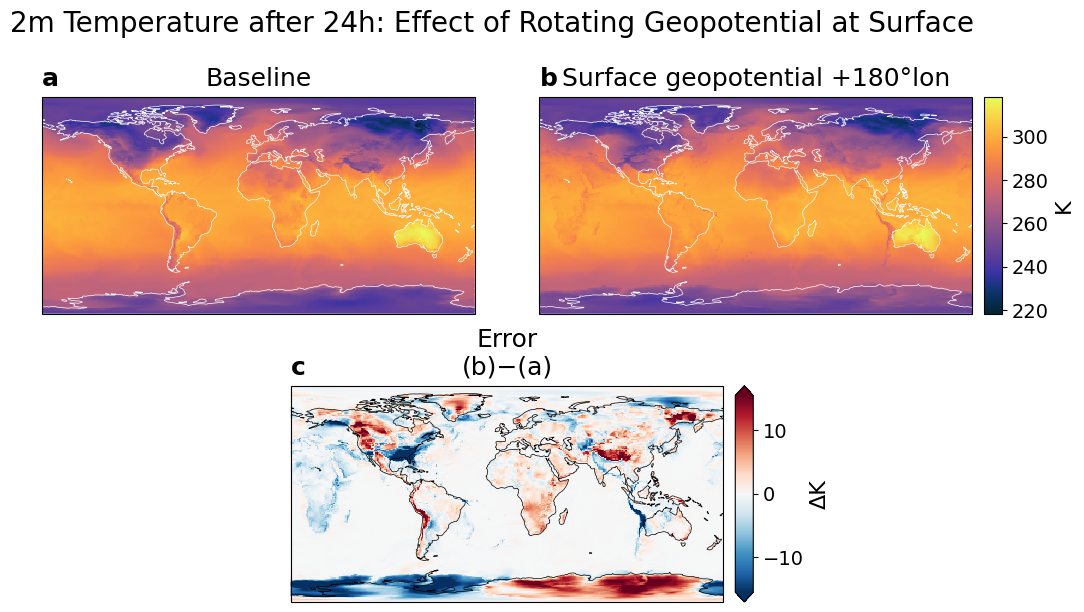

In [23]:
# ── User-adjustable settings ──────────────────────────────────────────────────
SNAPSHOT_DAY = 1
VAR          = "2m_temperature"
# ─────────────────────────────────────────────────────────────────────────────

time_idx = SNAPSHOT_DAY * 4 - 1

preds  = [sim1_pred, sim2_pred]
labels = ["Baseline", "Surface geopotential +180°lon"]

fields = [p[VAR].isel(time=time_idx).squeeze().values for p in preds]
diff   = fields[1] - fields[0]

lons = sim1_pred.lon.values
lats = sim1_pred.lat.values
proj = ccrs.PlateCarree()

# ── Colour scales ─────────────────────────────────────────────────────────────
vmin_a = min(f.min() for f in fields)
vmax_a = max(f.max() for f in fields)

diff_max = np.nanpercentile(np.abs(diff), 98)

# ── Figure: 2 rows × 2 cols via GridSpec ──────────────────────────────────────
fig = plt.figure(figsize=(12, 9))
fig.suptitle(
    f"2m Temperature after 24h: Effect of Rotating Geopotential at Surface",
    fontsize=20, y=0.93
)

gs = gridspec.GridSpec(2, 2, hspace=0.3, wspace=0.15)

# ── Row 0: Absolute fields (cols 0–1) ────────────────────────────────────────
top_axes = []
for i, (field, label) in enumerate(zip(fields, labels)):
    ax = fig.add_subplot(gs[0, i], projection=proj)
    ax.set_global()
    im_top = ax.pcolormesh(lons, lats, field,
                           vmin=vmin_a, vmax=vmax_a,
                           cmap=cmocean.cm.thermal, transform=proj)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="white")
    ax.set_title(label, fontsize=18, pad=8)
    top_axes.append(ax)

# ── Draw to lock positions before placing row 1 manually ─────────────────────
fig.canvas.draw()

p0 = [ax.get_position() for ax in top_axes]

col_w = p0[0].x1 - p0[0].x0
row_h = p0[0].y1 - p0[0].y0
gap   = 0.08

y0_row1 = p0[0].y0 - gap - row_h

# Diff panel: centred between the two top panels
diff_cx  = (p0[0].x1 + p0[1].x0) / 2
diff_pos = [diff_cx - col_w / 2, y0_row1, col_w, row_h]

# ── Row 1: Difference panel (centred) ─────────────────────────────────────────
ax_diff = fig.add_axes(diff_pos, projection=proj)
ax_diff.set_global()
im_diff = ax_diff.pcolormesh(lons, lats, diff,
                              vmin=-diff_max, vmax=diff_max,
                              cmap="RdBu_r", transform=proj)
ax_diff.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax_diff.set_title("Error\n(b)−(a)", fontsize=18, pad=8)

# ── Subplot labels (a, b, c — left-aligned) ───────────────────────────────────
_label_axes = [
    (top_axes[0], "a"),
    (top_axes[1], "b"),
    (ax_diff,     "c"),
]
for _ax, _lbl in _label_axes:
    _ax.set_title(_lbl, fontsize=18, fontweight="bold", loc="left", pad=8)

# ── Colorbars ──────────────────────────────────────────────────────────────────
fig.canvas.draw()
cbar_w, cbar_pad = 0.015, 0.01

# Row 0 thermal colorbar: right of top-right panel, matched to its height
pos = top_axes[-1].get_position()
cax1 = fig.add_axes([pos.x1 + cbar_pad, pos.y0, cbar_w, pos.y1 - pos.y0])
cb1  = fig.colorbar(im_top, cax=cax1)
cb1.set_label("K", fontsize=16)
cb1.ax.tick_params(labelsize=14)

# Row 1 diverging colorbar: right of diff panel, matched to its height
pos_d = ax_diff.get_position()
cax2 = fig.add_axes([pos_d.x1 + cbar_pad, pos_d.y0, cbar_w, pos_d.y1 - pos_d.y0])
cb2  = fig.colorbar(im_diff, cax=cax2, extend="both")
cb2.set_label("ΔK", fontsize=16)
cb2.ax.tick_params(labelsize=14)

plt.savefig("figures/rotated_geopotential_effect.png", dpi=300, bbox_inches="tight")
plt.show()

---
## Plot 4 -- Subset of Sample Input Data

Uses `example_batch` directly -- no simulation output needed for this one.


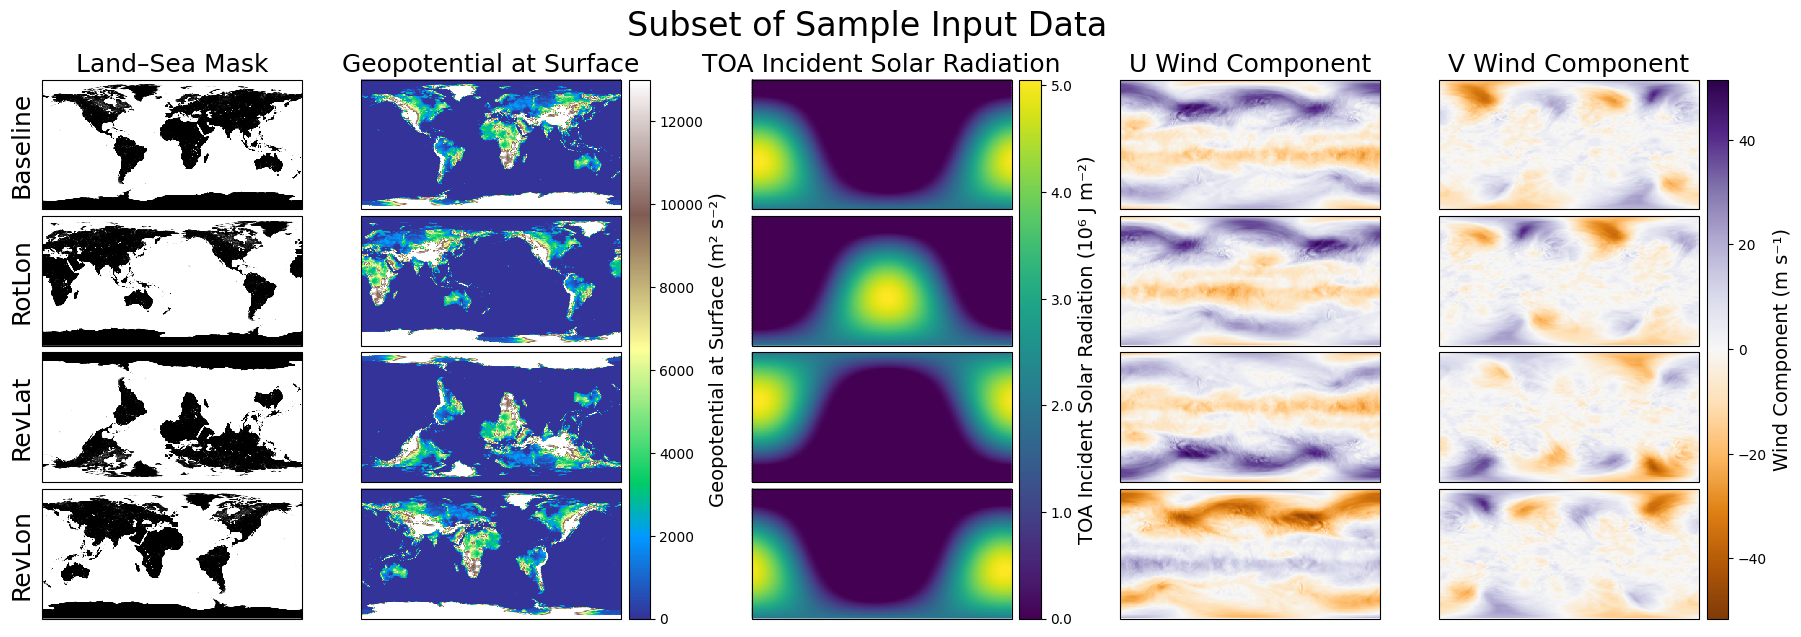

In [24]:
# ================================================================
# SUBSET OF SAMPLE INPUT DATA PLOT
# ================================================================
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# -------------------------
# Transformation functions
# -------------------------
def reverse_latitude(data):
    """Flip data north–south, keeping coordinate labels in place."""
    data = data.isel(lat=slice(None, None, -1)).assign_coords(lat=data.lat.values)
    data['v_component_of_wind'] = -1*data['v_component_of_wind']
    return data

def reverse_longitude(data):
    """Mirror data east–west, keeping coordinate labels in place."""
    data = data.isel(lon=slice(None, None, -1)).assign_coords(lon=data.lon.values)
    data['u_component_of_wind'] = -1*data['u_component_of_wind']
    return data

def rotate_longitude(data, shift_deg=180):
    """Cyclically roll data along longitude by shift_deg degrees."""
    n_lon = len(data.lon)
    shift_steps = round(shift_deg / 360 * n_lon)
    return data.roll(lon=shift_steps, roll_coords=False)

# -------------------------
# Build the 4 input datasets from sim1_ini
# -------------------------
ini_data   = [
    example_batch.copy(),
    rotate_longitude(example_batch.copy(), shift_deg=180),
    reverse_latitude(example_batch.copy()),
    reverse_longitude(example_batch.copy()),
]
ini_labels = ['Baseline', 'RotLon', 'RevLat', 'RevLon']

# -------------------------
# Settings
# -------------------------
var_names  = [
    'land_sea_mask',
    'geopotential_at_surface',
    'toa_incident_solar_radiation',
    'u_component_of_wind',
    'v_component_of_wind',
]
col_titles = [
    'Land–Sea Mask',
    'Geopotential at Surface',
    'TOA Incident Solar Radiation',
    'U Wind Component',
    'V Wind Component',
]
wind_vars  = {'u_component_of_wind', 'v_component_of_wind'}
n_rows, n_vars = len(ini_data), len(var_names)

# -------------------------
# Shared wind colour range
# -------------------------
global_wind_max = 0.0
for data in ini_data:
    for v in wind_vars:
        da = data[v]
        if   {'batch','time','level'}.issubset(da.dims): sl = da.isel(batch=0, time=0, level=0)
        elif {'batch','time'}.issubset(da.dims):         sl = da.isel(batch=0, time=0)
        else:                                            sl = da
        global_wind_max = max(global_wind_max, float(np.nanmax(np.abs(sl.values))))
wind_vmin, wind_vmax = -global_wind_max, global_wind_max

# -------------------------
# Figure + GridSpec
# -------------------------
subplot_w, subplot_h = 3.5, 1.75
fig = plt.figure(figsize=(subplot_w * 6.5, subplot_h * n_rows))

gs = gridspec.GridSpec(
    n_rows, 8,
    width_ratios=[1, 1, 0.22, 1, 0.15, 1, 1, 0.15],
    wspace=0.01, hspace=0.05,
)

def adjust_cbar(cax, shift=0.01, shrink=0.3):
    pos = cax.get_position()
    cax.set_position([pos.x0 - shift, pos.y0, pos.width * shrink, pos.height])
    
data_cols = [0, 1, 3, 5, 6]
axes = np.empty((n_rows, n_vars), dtype=object)
for r in range(n_rows):
    for c in range(n_vars):
        axes[r, c] = fig.add_subplot(gs[r, data_cols[c]], projection=ccrs.PlateCarree())

column_mappables = [None] * n_vars

# -------------------------
# Plotting loop
# -------------------------
for col_idx, var_name in enumerate(var_names):
    for row_idx, (data, label) in enumerate(zip(ini_data, ini_labels)):

        ax = axes[row_idx, col_idx]
        da = data[var_name]

        if   {'batch','time','level'}.issubset(da.dims): sl = da.isel(batch=0, time=0, level=0)
        elif {'batch','time'}.issubset(da.dims):         sl = da.isel(batch=0, time=0)
        else:                                            sl = da

        ax.set_extent([-180, 180, -90, 90])
        ax.set_xticks([]); ax.set_yticks([])
        #ax.coastlines(linewidth=0.4, color='white')

        if var_name in wind_vars:
            cmap, vmin, vmax = 'PuOr', wind_vmin, wind_vmax
        elif var_name == 'land_sea_mask':
            cmap, vmin, vmax = 'Greys', 0, 1
        elif var_name == 'geopotential_at_surface':
            cmap, vmin, vmax = 'terrain', 0, 13000
        else:  # TOA
            cmap = 'viridis'
            vmin = float(np.nanmin(sl.values))
            vmax = float(np.nanmax(sl.values))

        pcm = ax.pcolormesh(
            data.lon, data.lat, sl,
            cmap=cmap, vmin=vmin, vmax=vmax,
            shading='auto', transform=ccrs.PlateCarree()
        )

        if row_idx == 0:   ax.set_title(col_titles[col_idx], fontsize=18)
        if col_idx == 0:   ax.set_ylabel(label, fontsize=18, labelpad=6)
        if column_mappables[col_idx] is None:
            column_mappables[col_idx] = pcm

# -------------------------
# Colorbars
# -------------------------
fig.canvas.draw()

def adjust_cbar(cax, shift=0.01, shrink=0.45):
    pos = cax.get_position()
    cax.set_position([pos.x0 - shift, pos.y0, pos.width * shrink, pos.height])

cax_geo  = fig.add_subplot(gs[:, 2]);  adjust_cbar(cax_geo, shift=0.01, shrink=0.3)
cb = fig.colorbar(column_mappables[1], cax=cax_geo)
cb.set_label('Geopotential at Surface (m² s⁻²)', fontsize=14)

cax_toa = fig.add_subplot(gs[:, 4]); adjust_cbar(cax_toa)
cb_toa = fig.colorbar(column_mappables[2], cax=cax_toa)
cb_toa.set_label('TOA Incident Solar Radiation (10⁶ J m⁻²)', fontsize=14)
cb_toa.ax.yaxis.set_major_formatter(lambda x, _: f'{x / 1e6:.1f}')

cax_wind = fig.add_subplot(gs[:, 7]); adjust_cbar(cax_wind)
cb_wind = fig.colorbar(column_mappables[4], cax=cax_wind)
cb_wind.set_label('Wind Component (m s⁻¹)', fontsize=14)

fig.suptitle('Subset of Sample Input Data', fontsize=24, y=0.98)
plt.savefig("figures/input_transformations_overview.jpeg", dpi=800, bbox_inches='tight')
plt.show()